# Time Seriese

This notebook will test out different time series models and look at there strength and weekneses.

## Libraries

**Important:**

Install numpy 2.0 instead of the newest version, because Darts still works on the old versions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from darts import TimeSeries
from darts.models import ARIMA, ExponentialSmoothing, Prophet
from darts.utils.utils import ModelMode, SeasonalityMode
from darts.metrics import mae, mape, rmse


/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

In [2]:
path = "../data/procesed/"

random_seed = 42

## Loading Timeseries ABT

Loading the timeseries ABT from procesed folder.

In [3]:
timeseries = pd.read_csv(path+"timeseries_ABT.csv")

timeseries.head()

,Unnamed: 0,unit_sales,year,month,day,day_of_week,is_holiday,dcoilwtico,is_payday,is_earthquake
0,2013-01-02,582.0,2013,1,2,2,0,93.14,0,0
1,2013-01-03,310.0,2013,1,3,3,0,92.97,0,0
2,2013-01-04,338.0,2013,1,4,4,0,93.12,0,0
3,2013-01-05,654.0,2013,1,5,5,1,93.12,0,0
4,2013-01-06,979.0,2013,1,6,6,0,93.12,0,0


In [4]:
timeseries.columns = ['date', 'unit_sales', 'year', 'month', 'day', 'day_of_week', 'is_holiday', 'dcoilwtico', 'is_payday', 'is_earthquake']
timeseries['date'] = pd.to_datetime(timeseries['date'])
timeseries.set_index('date', inplace=True)

> Convert Pandas Series to Dart Series

In [5]:
series = TimeSeries.from_dataframe(timeseries, value_cols='unit_sales')

# Models

In [9]:
# splitting the data into 80% training and 20 testing
train, test = series.split_after(0.8)

In [10]:
#eXogenous factors
covariates = TimeSeries.from_dataframe(timeseries, value_cols=['day_of_week', 'is_holiday', 'dcoilwtico', 'is_payday'])

## AR

AR model is nothing else than a constrained ARIMA model to (p,0,0).

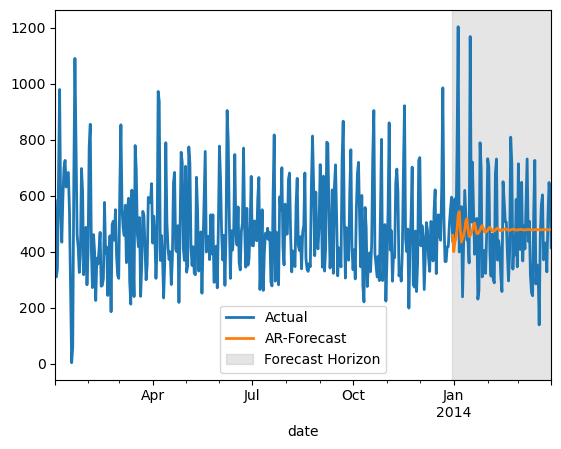

MAPE: 32.312358016009796%
RMSE: 181.42221914827095


In [9]:
# Train Model
ar_model = ARIMA(p=7,d=0,q=0)
ar_model.fit(train)
ar_prediction = ar_model.predict(n=len(test))

# Plot Model and Forecast
series.plot(label='Actual')
ar_prediction.plot(label='AR-Forecast', low_quantile=0.05, high_quantile=0.95)
# Get the "split point" (the last timestamp of the training data)
split_date = train.end_time()

# Add the shaded region
# plt.axvspan(start, end, color, alpha)
plt.axvspan(split_date, series.end_time(), color='gray', alpha=0.2, label='Forecast Horizon')
plt.legend()
plt.show()

# Evaluate Model
print(f"MAPE: {mape(test, ar_prediction)}%")
print(f"RMSE: {rmse(test, ar_prediction)}")

## MA

MA model is nothing else than a constrained ARIMA model to (0,0,q).

/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


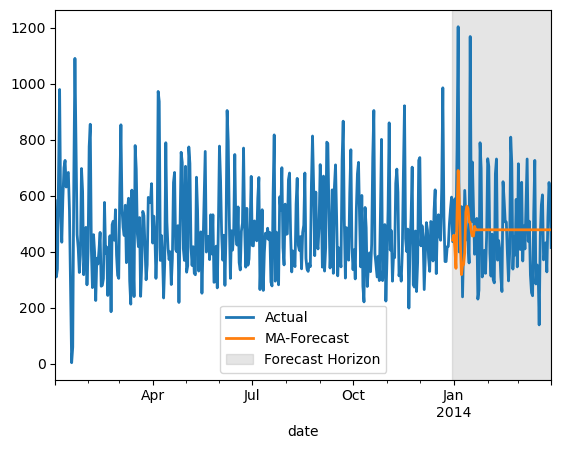

MAPE: 33.1509735682328%
RMSE: 177.45201979139057


In [10]:
# Train Model
ma_model = ARIMA(p=0,d=0,q=21)
ma_model.fit(train)
ma_prediction = ma_model.predict(n=len(test))

# Plot Model and Forecast
series.plot(label='Actual')
ma_prediction.plot(label='MA-Forecast', low_quantile=0.05, high_quantile=0.95)
# Get the "split point" (the last timestamp of the training data)
split_date = train.end_time()

# Add the shaded region
# plt.axvspan(start, end, color, alpha)
plt.axvspan(split_date, series.end_time(), color='gray', alpha=0.2, label='Forecast Horizon')
plt.legend()
plt.show()

# Evaluate Model
print(f"MAPE: {mape(test, ma_prediction)}%")
print(f"RMSE: {rmse(test, ma_prediction)}")

## ARMA

/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


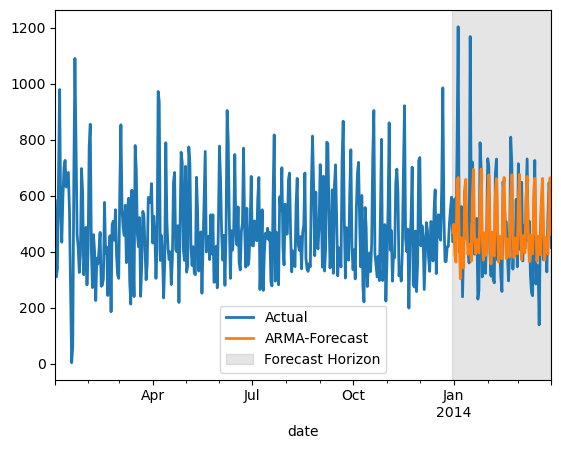

MAPE: 24.070860707488745%
RMSE: 145.44895955218936


In [11]:
# Train Model
arma_model = ARIMA(p=7,d=0,q=21)
arma_model.fit(train)
arma_prediction = arma_model.predict(n=len(test))

# Plot Model and Forecast
series.plot(label='Actual')
arma_prediction.plot(label='ARMA-Forecast', low_quantile=0.05, high_quantile=0.95)
# Get the "split point" (the last timestamp of the training data)
split_date = train.end_time()

# Add the shaded region
# plt.axvspan(start, end, color, alpha)
plt.axvspan(split_date, series.end_time(), color='gray', alpha=0.2, label='Forecast Horizon')
plt.legend()
plt.show()

# Evaluate Model
print(f"MAPE: {mape(test, arma_prediction)}%")
print(f"RMSE: {rmse(test, arma_prediction)}")

## ARIMA

### d

<Axes: title={'center': 'Raw unit_sales (d=0)'}, xlabel='date'>

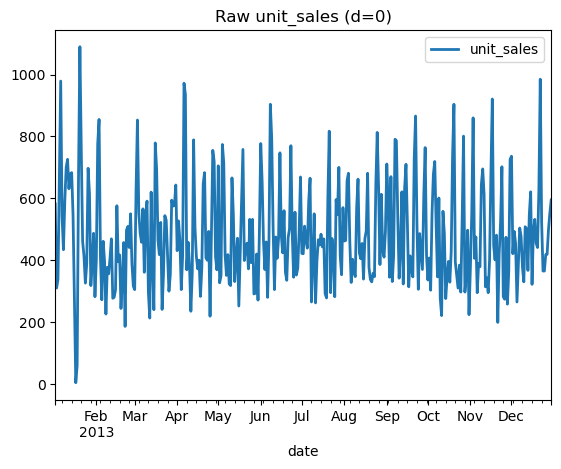

In [12]:
train.plot(title="Raw unit_sales (d=0)")

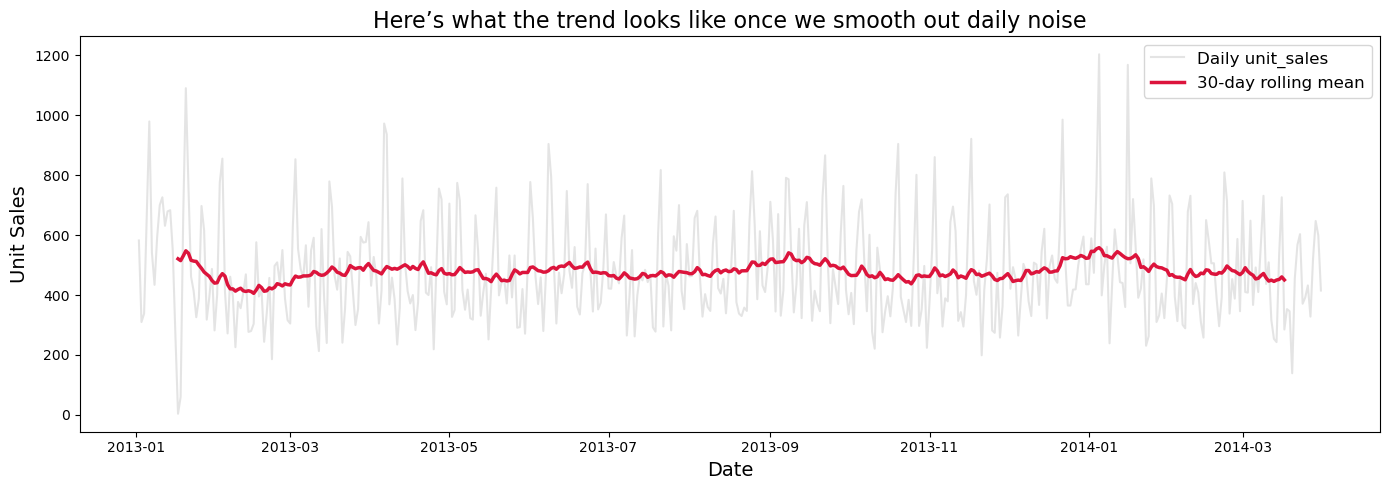

In [13]:
# Compute a 30-day rolling average to smooth out the daily noise
rolling_trend = timeseries['unit_sales'].rolling(window=30, center=True).mean()

plt.figure(figsize=(14, 5))
# Plot the raw daily sales in light gray
plt.plot(timeseries.index, timeseries['unit_sales'],
         color='lightgray', alpha=0.6, label='Daily unit_sales')
# Overlay the 30-day rolling mean in a bold color
plt.plot(rolling_trend.index, rolling_trend.values,
         color='crimson', linewidth=2.5, label='30-day rolling mean')

plt.title("Here’s what the trend looks like once we smooth out daily noise", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Unit Sales", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
result = adfuller(train.values().flatten()) # adfuller can not handle DARTS TimeSeries objects this why you have to transform it to an numpy array.
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print(f"The time series is {'stationary' if result[1] < 0.05 else 'non-stationary'} based on the ADF test.")

ADF Statistic: -4.209405971486785
p-value: 0.0006351558691093173
The time series is stationary based on the ADF test.


A low ADF p-value (<0.05) technically tells you “reject the unit-root null → series is stationary”. Since our p-value is very small (≪ 0.05), you can reject the null hypothesis with high confidence, and you don’t need to difference the series (d=0) for models like ARIMA.
But even though you got a tiny p-value at d=0, we will go ahead and try d=1 to show you how is done, in case you get a series that needs to be differenced.

> to create differences use numpy

diff1 = np.diff(train.values().flatten(), 1)

### p

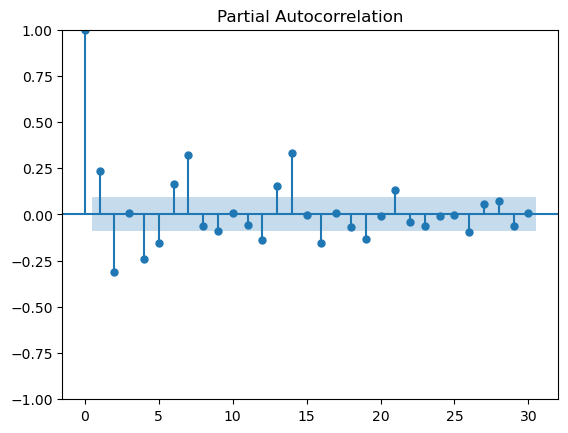

In [15]:
# lags=30 shows correlations up to 30 past days (≈1 month), helping identify how far back autocorrelations persist.  
plot_pacf(timeseries.unit_sales, lags=30)  
plt.show()

What We See in Our Plot
Lag 0 always shows a correlation of 1.0, since a series is perfectly correlated with itself. 
Starting from lag 1, we see a strong positive correlation, which is expected in many time series — recent values are often highly predictive of the next one.
After lag 1, several early lags (up to lag 6) show significant negative partial autocorrelations (outside the gray confidence interval).
Most lags after 10 fall within the confidence bounds, indicating that their partial correlations are not statistically significant.

> p = 1-7

## q

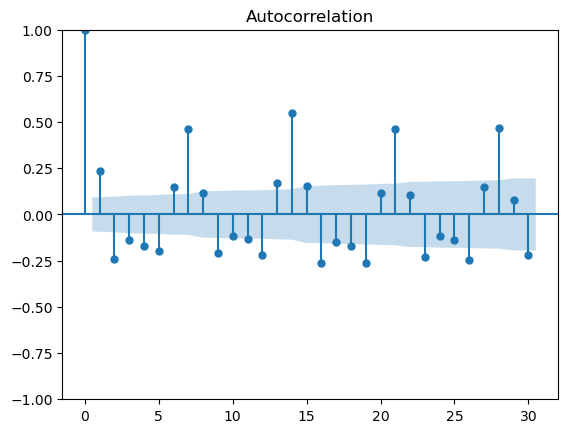

In [16]:
plot_acf(timeseries.unit_sales, lags=30) # lags=30 = how far back we look
plt.show()

| Features you see | What it means |
| --- | --- |
| Repeating positive lag spikes at 7,14,21 | clear 7 day seasonality recommended to use SARIMA |
| Alternating negative bars between those weekly spikes | Typical of a seasonal pattern: values half a cycle away (≈ 3–4 days) move in the opposite direction. |
| No single sharp cut-off after a few lags | The series is not a simple MA(q) process; seasonality dominates the autocorrelation structure. |

### ARIMA 

| Metric | What it tells us | Rule |
| --- | --- | --- |
|AIC / BIC|Penalise bad fit and unnecessary complexity. For comparing models.|Lower = better|
|Validation error (e.g., MAE, RMSE)|How well the model predicts unseen data|Lower = better

<Axes: xlabel='date'>

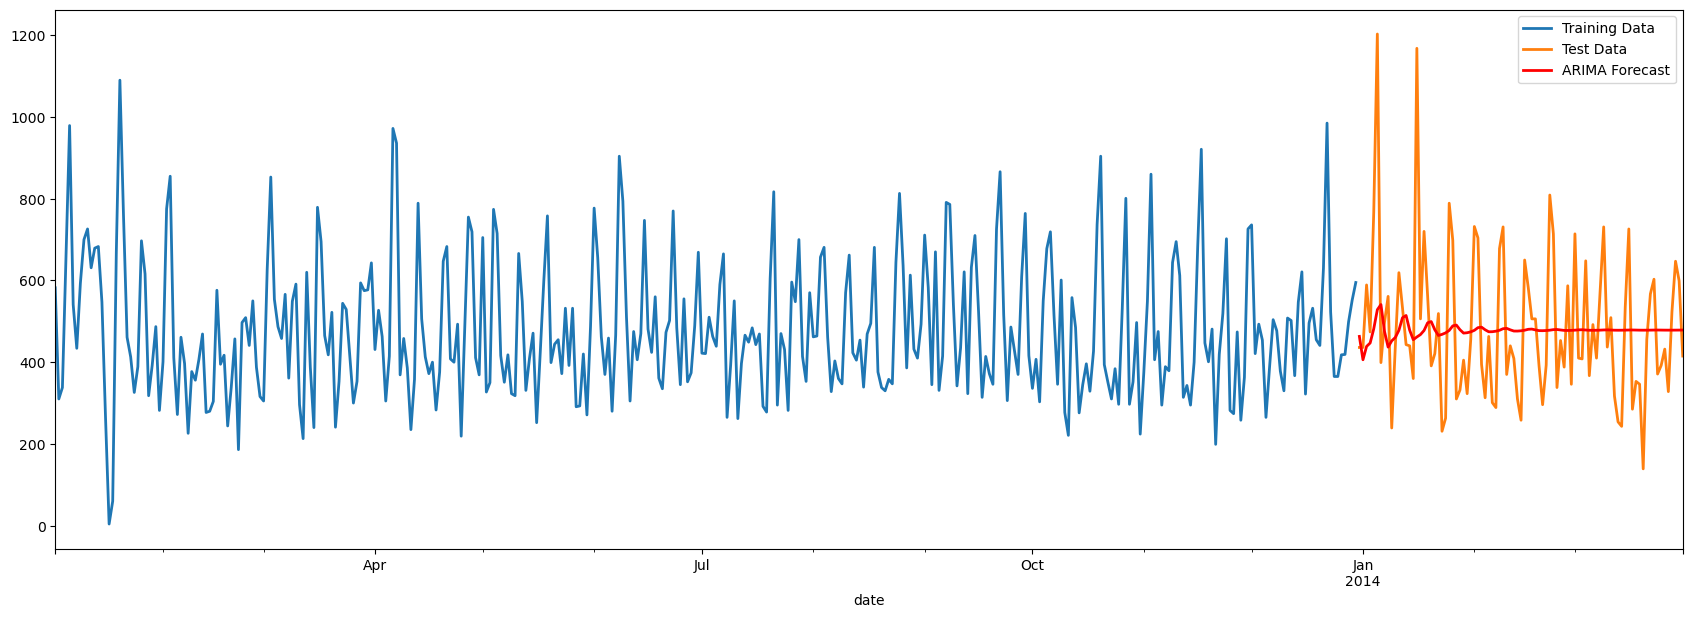

In [17]:
arima_model = ARIMA(p=7,d=0,q=1)

arima_model.fit(train)

arima_forecast = arima_model.predict(len(test))

# Plot ARIMA forecast vs actual data
plt.figure(figsize=(21, 7))
train.plot(label='Training Data')
test.plot(label='Test Data')
arima_forecast.plot(label='ARIMA Forecast', color='red')

|Aspect|What we see|Interpretation|
|---|---|---|
|Fit on first few test points|The red line rises with the first three blue points, then flattens|ARIMA is using recent lags, so it reacts at the start of the forecast window, but its memory fades quickly|
|Remainder of test window|Forecast drifts to a nearly flat band (≈ 450–500 units) while the blue line whipsaws between 150 and 1200|Model has reverted to predicting the long-run mean, failing to track the volatility and the big weekly peaks|

In [18]:
ps = [1,2,3,4,5,6,7]
ds = [0,1]
qs = [0,1,2,3,4,5,6,7]

result_dict = {}

for p in ps:
    for d in ds:
        for q in qs:
            arima_model = ARIMA(p=p,d=d,q=q)
            arima_model.fit(train)
            arima_forecast = arima_model.predict(len(test))
            # Evaluate one model
            aic_value = arima_model.model.aic
            mae_value   = mae(test , arima_forecast)
            mape_value = mape(test,arima_forecast)
            model_name = f"ARIMA({p},{d},{q})"
            result_dict[model_name] = {
                "p": p,
                "d": d,
                "q": q,
                "AIC": aic_value,
                "MAPE": mape_value,
                "MAE": mae_value
            }

# Convert your result_dict to a DataFrame
df = pd.DataFrame.from_dict(result_dict, orient='index')

print("Best ARIMA model:")
df.sort_values(['AIC'],ascending=[True])[0:5]



/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conv

Best ARIMA model:


/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,d,q,AIC,MAPE,MAE
"ARIMA(5,1,7)",5,1,7,4492.596367,23.613207,102.141603
"ARIMA(7,1,7)",7,1,7,4493.391769,23.994034,102.901688
"ARIMA(7,1,6)",7,1,6,4494.861627,23.743252,102.733117
"ARIMA(5,0,7)",5,0,7,4495.055380,23.598796,102.286028
"ARIMA(6,1,6)",6,1,6,4496.883044,23.847611,103.090684


## SARIMA

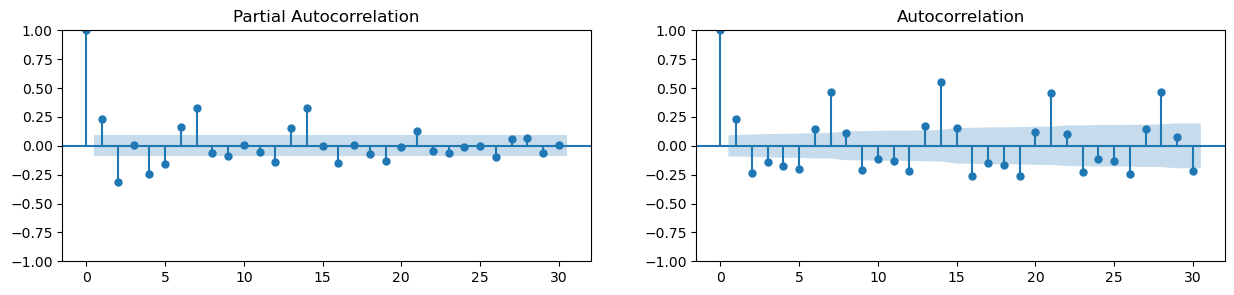

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 3))
# lags=30 shows correlations up to 30 past days (≈1 month), helping identify how far back autocorrelations persist.  
plot_pacf(timeseries.unit_sales, lags=30, ax=ax[0])  
plot_acf(timeseries.unit_sales, lags=30, ax=ax[1]) # lags=30 = how far back we look
plt.show()

**Period:** 7 days

**P:** 1, it has a sharp drop of after 1

**Q:** 1, it has a sharp drop of after 1

/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


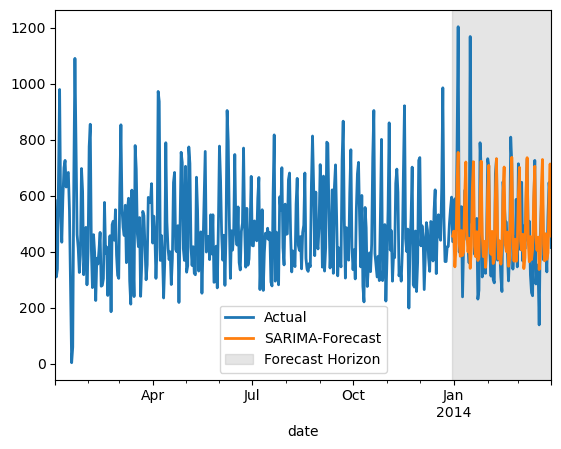

MAPE: 21.734389457268488%
RMSE: 142.8326124039821


In [20]:
# Train Model
sarima_model = ARIMA(p=5,d=0,q=6, seasonal_order=(1, 1, 1, 7)) # Q*s is not allowed to be equal to q!
sarima_model.fit(train)
sarima_prediction = sarima_model.predict(n=len(test))

# Plot Model and Forecast
series.plot(label='Actual')
sarima_prediction.plot(label='SARIMA-Forecast', low_quantile=0.05, high_quantile=0.95)
# Get the "split point" (the last timestamp of the training data)
split_date = train.end_time()

# Add the shaded region
# plt.axvspan(start, end, color, alpha)
plt.axvspan(split_date, series.end_time(), color='gray', alpha=0.2, label='Forecast Horizon')
plt.legend()
plt.show()

# Evaluate Model
print(f"MAPE: {mape(test, sarima_prediction)}%")
print(f"RMSE: {rmse(test, sarima_prediction)}")

/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimizatio

Best Parameters found: {'p': 5, 'd': 1, 'q': 1, 'seasonal_order': (1, 1, 1, 7)}


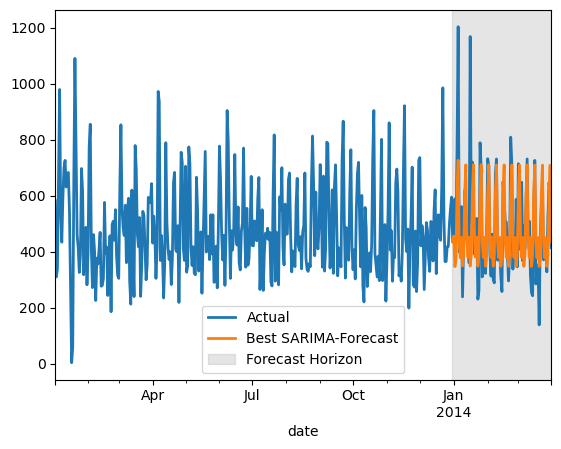

MAPE: 20.880265396723544%
RMSE: 142.7151328135475


In [21]:
# Darts makes grid search trivial
grid_model = ARIMA.gridsearch(
    parameters={
        'p': [1,5],
        'd': [1],
        'q': [1,3],
        'seasonal_order': [(1, 1, 1, 7)]
    },
    series=train,
    forecast_horizon=14,
    metric=mape,
    n_jobs=-1
)

print(f"Best Parameters found: {grid_model[1]}")
grid_model[0].fit(train)
best_sarima_prediction = grid_model[0].predict(len(test))

# Plot Model and Forecast
series.plot(label='Actual')
best_sarima_prediction.plot(label='Best SARIMA-Forecast', low_quantile=0.05, high_quantile=0.95)
# Get the "split point" (the last timestamp of the training data)
split_date = train.end_time()

# Add the shaded region
# plt.axvspan(start, end, color, alpha)
plt.axvspan(split_date, series.end_time(), color='gray', alpha=0.2, label='Forecast Horizon')
plt.legend()
plt.show()

# Evaluate Model
print(f"MAPE: {mape(test, best_sarima_prediction)}%")
print(f"RMSE: {rmse(test, best_sarima_prediction)}")

## SARIMAX

/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


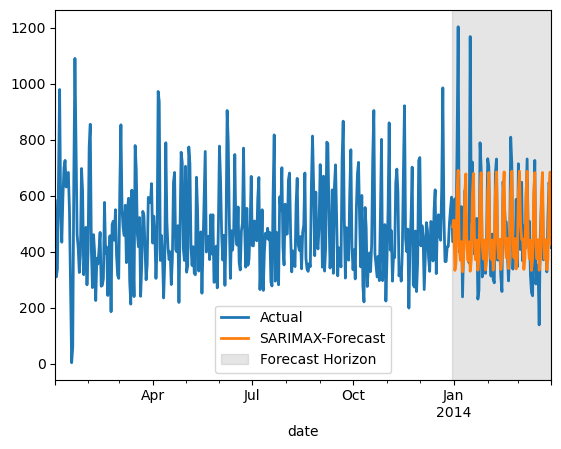

MAPE: 20.371548044443692%
RMSE: 142.82449164311143


In [22]:
# Define your SARIMA parameters as usual
sarimax = ARIMA(
    p=5, d=1, q=1, 
    seasonal_order=(1, 1, 1, 7)
)

# SARIMAX = ARIMA + future_covariates
sarimax.fit(
    series=train, 
    future_covariates=covariates # This makes it a SARIMAX
)
sarimax_prediction = sarimax.predict(
    n=len(test), 
    future_covariates=covariates 
)

# Plot Model and Forecast
series.plot(label='Actual')
sarimax_prediction.plot(label='SARIMAX-Forecast', low_quantile=0.05, high_quantile=0.95)
# Get the "split point" (the last timestamp of the training data)
split_date = train.end_time()

# Add the shaded region
# plt.axvspan(start, end, color, alpha)
plt.axvspan(split_date, series.end_time(), color='gray', alpha=0.2, label='Forecast Horizon')
plt.legend()
plt.show()

# Evaluate Model
print(f"MAPE: {mape(test, sarimax_prediction)}%")
print(f"RMSE: {rmse(test, sarimax_prediction)}")

## Single Exponential Smoothing

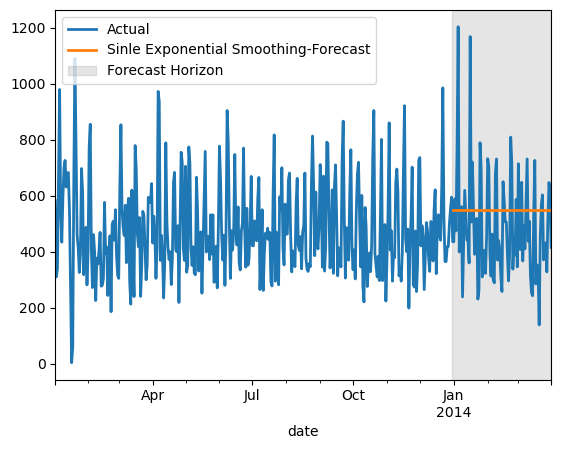

MAPE: 41.29225296319191%
RMSE: 194.09702300111076


In [23]:
# Define your SARIMA parameters as usual
single_exp_smooth = ExponentialSmoothing(
    trend=None, 
    seasonal=None, 
    smoothing_level=0.5  # This is your 'alpha' parameter
)

single_exp_smooth.fit(train)
single_exp_smooth_prediction = single_exp_smooth.predict(len(test))

# Plot Model and Forecast
series.plot(label='Actual')
single_exp_smooth_prediction.plot(label='Sinle Exponential Smoothing-Forecast', low_quantile=0.05, high_quantile=0.95)
# Get the "split point" (the last timestamp of the training data)
split_date = train.end_time()

# Add the shaded region
# plt.axvspan(start, end, color, alpha)
plt.axvspan(split_date, series.end_time(), color='gray', alpha=0.2, label='Forecast Horizon')
plt.legend()
plt.show()

# Evaluate Model
print(f"MAPE: {mape(test, single_exp_smooth_prediction)}%")
print(f"RMSE: {rmse(test, single_exp_smooth_prediction)}")

## Double Exponential Smoothing

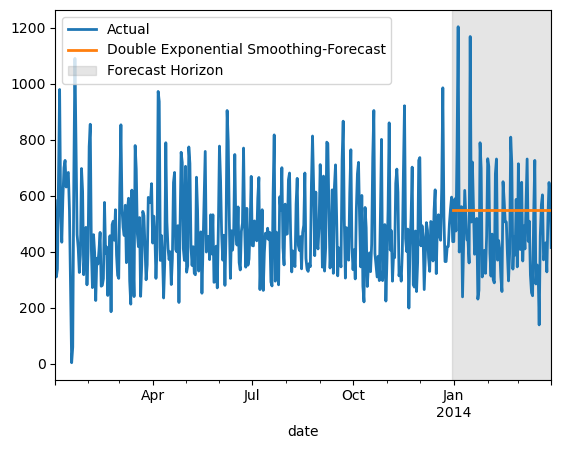

MAPE: 41.29225296319191%
RMSE: 194.09702300111076


In [24]:
# Define your SARIMA parameters as usual
double_exp_smooth = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE, 
    seasonal=None,
    random_state = random_seed,
    smoothing_level=0.5,    # This is your 'alpha' parameter
    damped=0.9      # Optional: prevents the trend from projecting to infinity
)

double_exp_smooth.fit(train)
double_exp_smooth_prediction = double_exp_smooth.predict(len(test))

# Plot Model and Forecast
series.plot(label='Actual')
double_exp_smooth_prediction.plot(label='Double Exponential Smoothing-Forecast', low_quantile=0.05, high_quantile=0.95)
# Get the "split point" (the last timestamp of the training data)
split_date = train.end_time()

# Add the shaded region
# plt.axvspan(start, end, color, alpha)
plt.axvspan(split_date, series.end_time(), color='gray', alpha=0.2, label='Forecast Horizon')
plt.legend()
plt.show()

# Evaluate Model
print(f"MAPE: {mape(test, double_exp_smooth_prediction)}%")
print(f"RMSE: {rmse(test, double_exp_smooth_prediction)}")

## Triple Exponential Smoothing

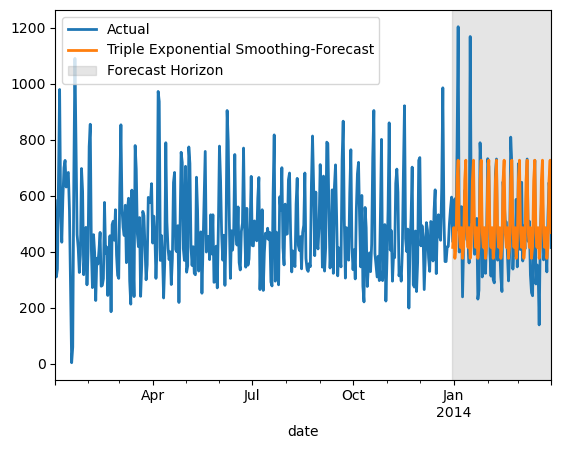

MAPE: 23.631306586618628%
RMSE: 143.74026124038167


In [25]:
# Define your SARIMA parameters as usual
triple_exp_smooth = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE, 
    seasonal=SeasonalityMode.ADDITIVE,
    seasonal_periods= 7,
    random_state = random_seed,
    smoothing_level=0.5,    # This is your 'alpha' parameter
    damped=0.9      # Optional: prevents the trend from projecting to infinity
)

triple_exp_smooth.fit(train)
triple_exp_smooth_prediction = triple_exp_smooth.predict(len(test))

# Plot Model and Forecast
series.plot(label='Actual')
triple_exp_smooth_prediction.plot(label='Triple Exponential Smoothing-Forecast', low_quantile=0.05, high_quantile=0.95)
# Get the "split point" (the last timestamp of the training data)
split_date = train.end_time()

# Add the shaded region
# plt.axvspan(start, end, color, alpha)
plt.axvspan(split_date, series.end_time(), color='gray', alpha=0.2, label='Forecast Horizon')
plt.legend()
plt.show()

# Evaluate Model
print(f"MAPE: {mape(test, triple_exp_smooth_prediction)}%")
print(f"RMSE: {rmse(test, triple_exp_smooth_prediction)}")

## Prophet Model

**holiday dataframe structure**

custom_holidays = pd.DataFrame({

  'holiday': 'company_event',
  
  'ds': pd.to_datetime(['2023-05-01', '2024-05-01']),
  
  'lower_window': 0, # Days before event to include
  
  'upper_window': 1  # Days after event to include

})

In [13]:
holidays = pd.read_csv(path+"holidays.csv")

holidays = holidays.rename(columns={'date': 'ds', 'description': 'holiday'})

holidays = holidays.drop(columns=['Unnamed: 0', 'locale', 'locale_name'])

holidays['lower_window'] = 0
holidays['upper_window'] = 1

holidays.head()

,ds,holiday,lower_window,upper_window
0,2012-08-10,Primer Grito de Independencia,0,1
1,2012-10-09,Independencia de Guayaquil,0,1
2,2012-10-12,Traslado Independencia de Guayaquil,0,1
3,2012-11-02,Dia de Difuntos,0,1
4,2012-11-03,Independencia de Cuenca,0,1


15:22:53 - cmdstanpy - INFO - Chain [1] start processing
15:22:54 - cmdstanpy - INFO - Chain [1] done processing


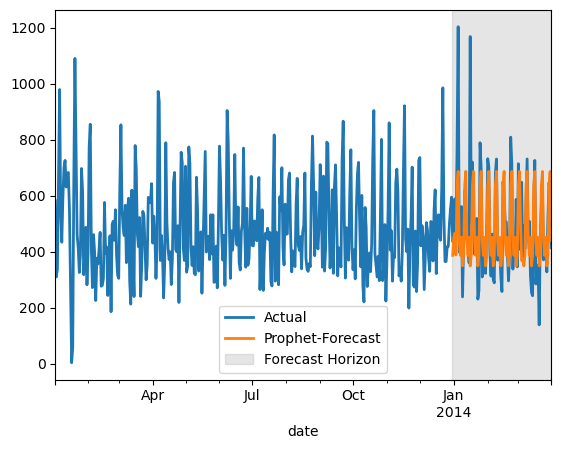

MAPE: 20.526266686631146%
RMSE: 139.99912903771758


In [14]:
# Define your SARIMA parameters as usual


prophet = Prophet(
    # --- TREND ---
    # 'linear' or 'logistic'. If logistic, you must provide 'cap' and 'floor'
    growth='linear', 
    changepoint_prior_scale=0.05, # Higher = more flexible trend
    
    # --- SEASONALITY ---
    # Built-in seasonalities are True/False or 'auto'
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,

    holidays=holidays
)

prophet.fit(train)
prophet_prediction = prophet.predict(len(test))

# Plot Model and Forecast
series.plot(label='Actual')
prophet_prediction.plot(label='Prophet-Forecast', low_quantile=0.05, high_quantile=0.95)
# Get the "split point" (the last timestamp of the training data)
split_date = train.end_time()

# Add the shaded region
# plt.axvspan(start, end, color, alpha)
plt.axvspan(split_date, series.end_time(), color='gray', alpha=0.2, label='Forecast Horizon')
plt.legend()
plt.show()

# Evaluate Model
print(f"MAPE: {mape(test, prophet_prediction)}%")
print(f"RMSE: {rmse(test, prophet_prediction)}")

15:25:25 - cmdstanpy - INFO - Chain [1] start processing
15:25:25 - cmdstanpy - INFO - Chain [1] done processing


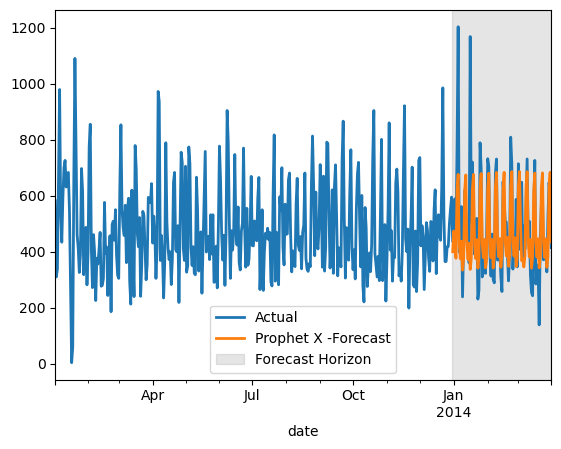

MAPE: 20.17822914561366%
RMSE: 141.16022961079665


In [15]:
# Define your SARIMA parameters as usual


prophet_x = Prophet(
    # --- TREND ---
    # 'linear' or 'logistic'. If logistic, you must provide 'cap' and 'floor'
    growth='linear', 
    changepoint_prior_scale=0.05, # Higher = more flexible trend
    
    # --- SEASONALITY ---
    # Built-in seasonalities are True/False or 'auto'
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,

    holidays=holidays
)

prophet_x.fit(series=train, future_covariates=covariates)
prophet_x_prediction = prophet_x.predict(len(test))

# Plot Model and Forecast
series.plot(label='Actual')
prophet_x_prediction.plot(label='Prophet X -Forecast', low_quantile=0.05, high_quantile=0.95)
# Get the "split point" (the last timestamp of the training data)
split_date = train.end_time()

# Add the shaded region
# plt.axvspan(start, end, color, alpha)
plt.axvspan(split_date, series.end_time(), color='gray', alpha=0.2, label='Forecast Horizon')
plt.legend()
plt.show()

# Evaluate Model
print(f"MAPE: {mape(test, prophet_x_prediction)}%")
print(f"RMSE: {rmse(test, prophet_x_prediction)}")

# Feature Engineering

- Lags
- Rolling Average (Rolling Window)
- Expanding Window (comulative average)

> **Always use exluding Windows: To Avoid Information Lekage**

## Machine Learning Models